# Overview Learning Curves

Goal: compare learning dynamics across algorithms from many angles.

Expected takeaway: which methods learn faster, reach higher final scores, and maintain stable improvements across pass@k.


In [6]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




combined_path = resolve_data_path("combined_wide.csv")
combined = pd.read_csv(combined_path)
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")

metric_cols = ["avg@32", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

# Helpers
PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [7]:
# Identify top algorithms per metric at final step
final_rows = agg[agg["Step"] == final_step].copy()

def top_algorithms(metric, top_n=6):
    ranking = final_rows.sort_values(metric, ascending=False)
    return ranking["algorithm"].head(top_n).tolist()


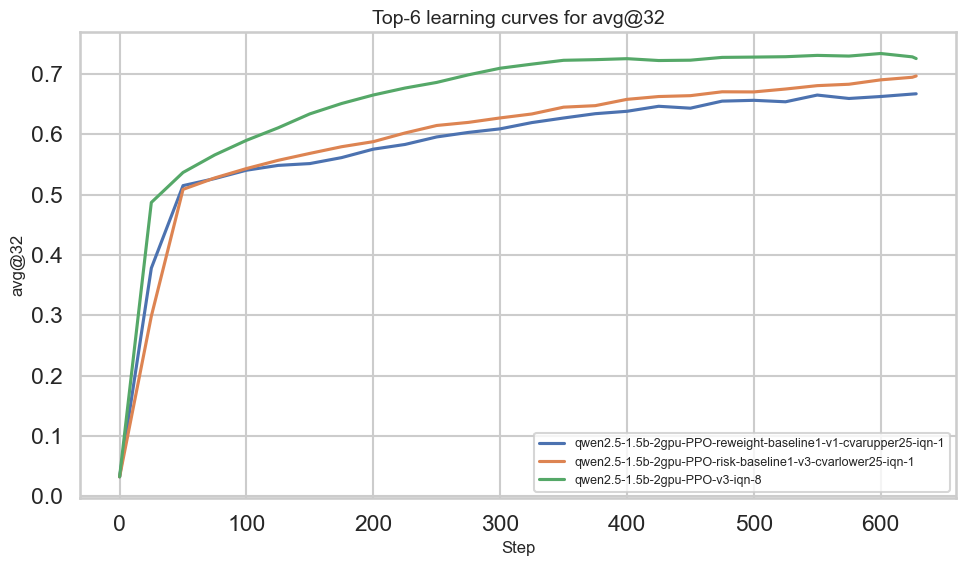

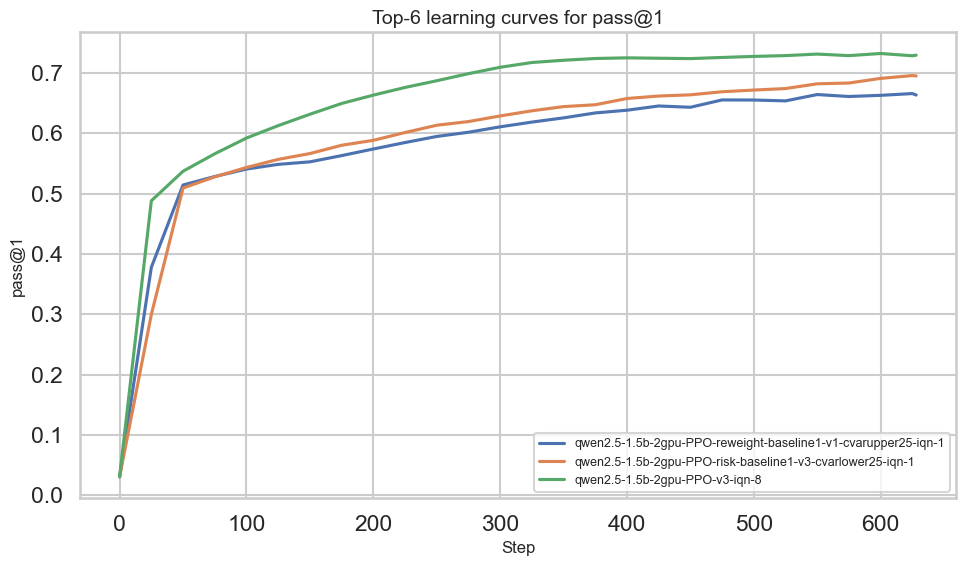

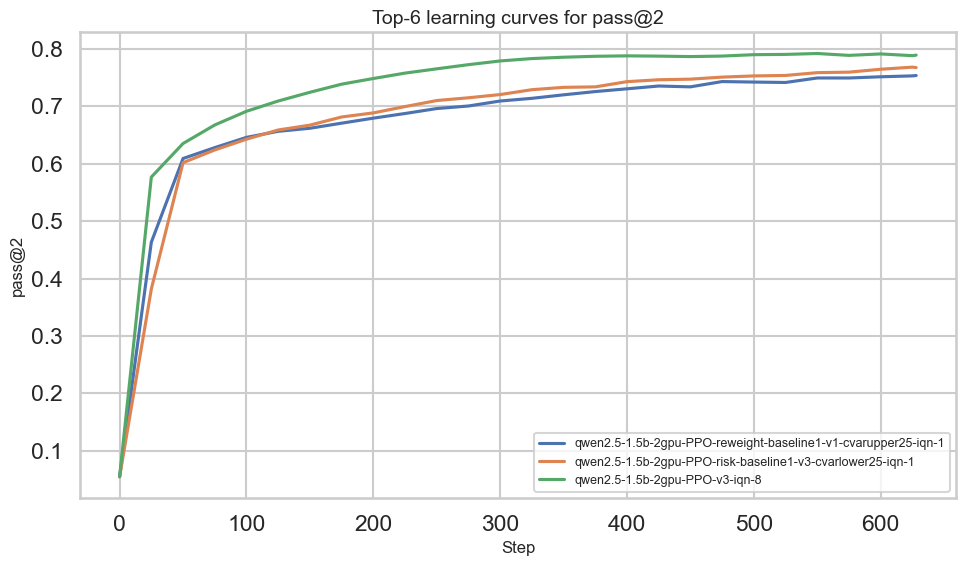

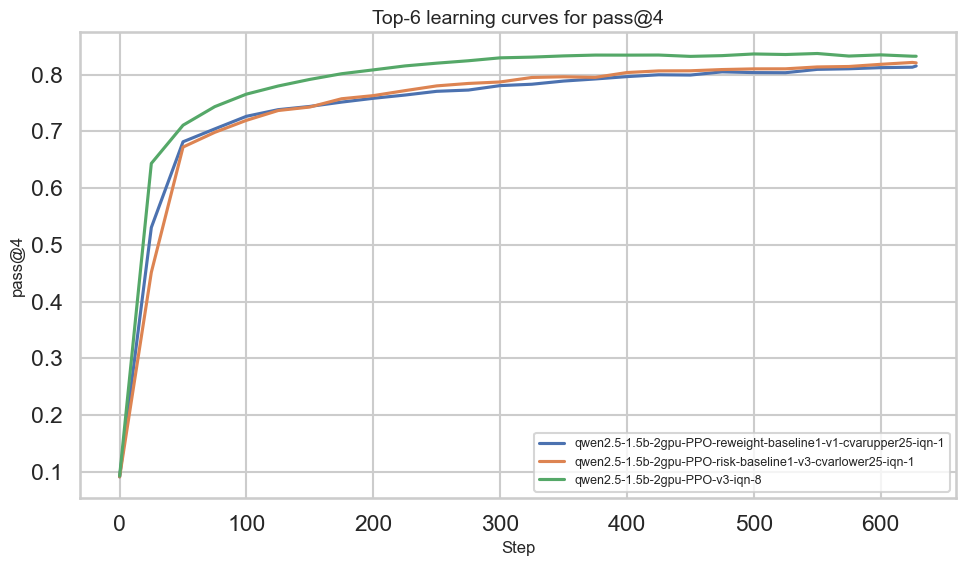

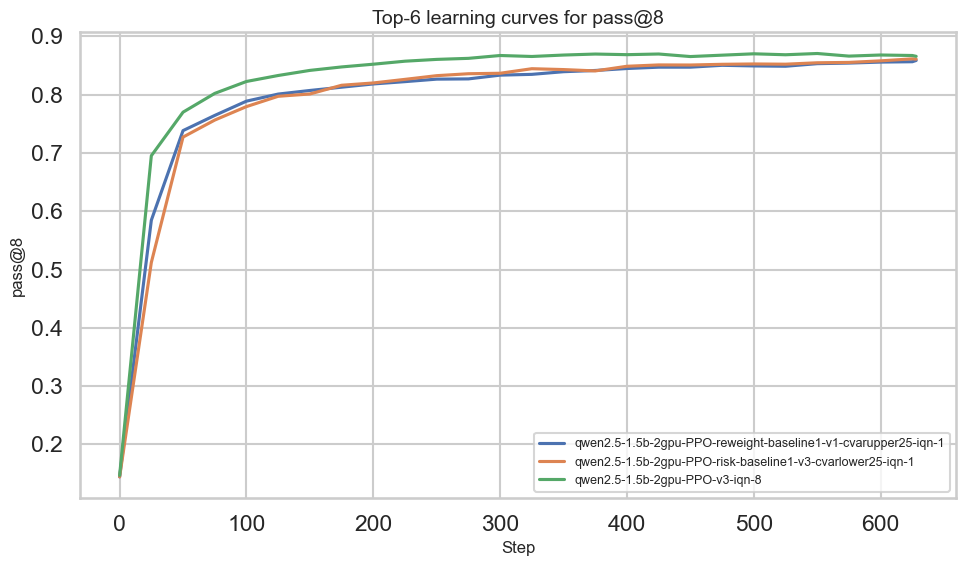

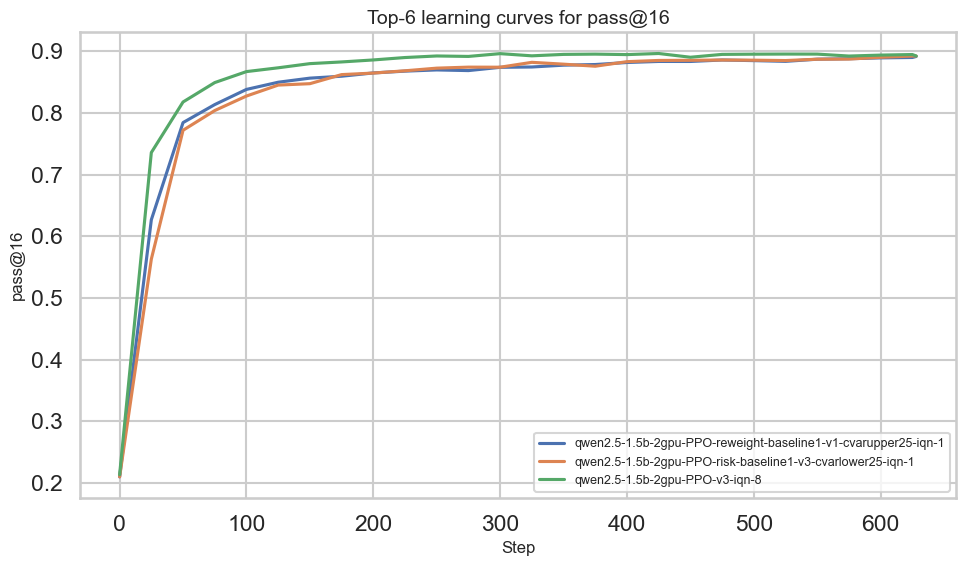

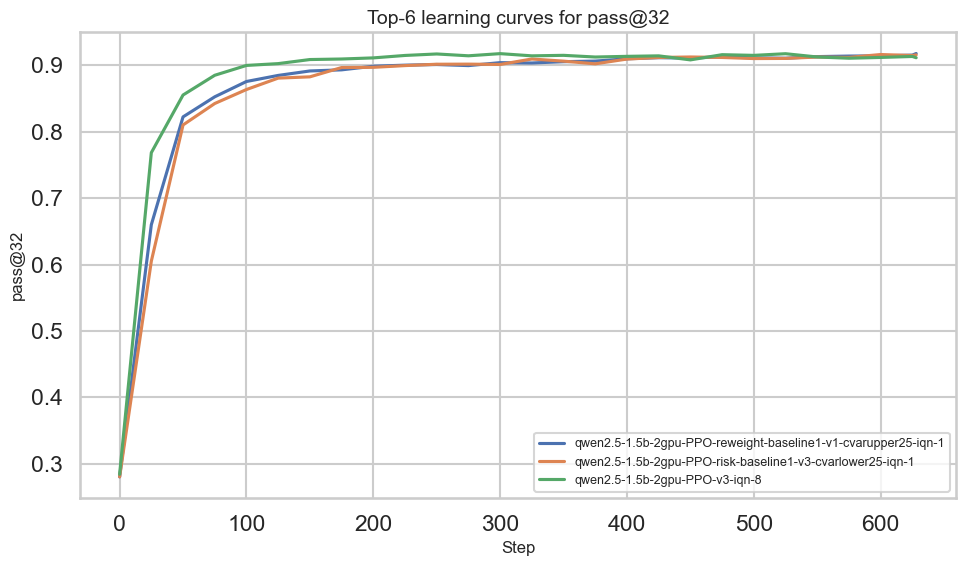

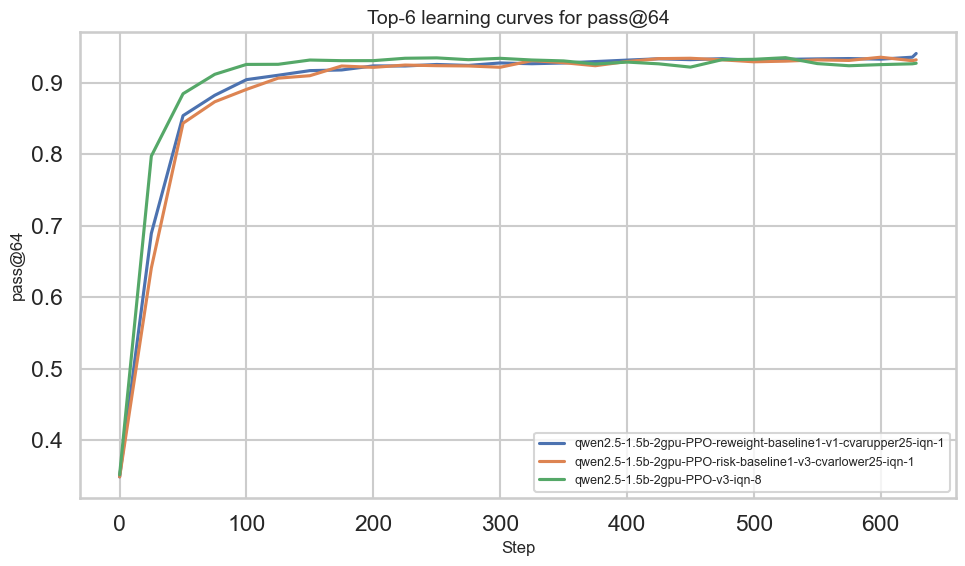

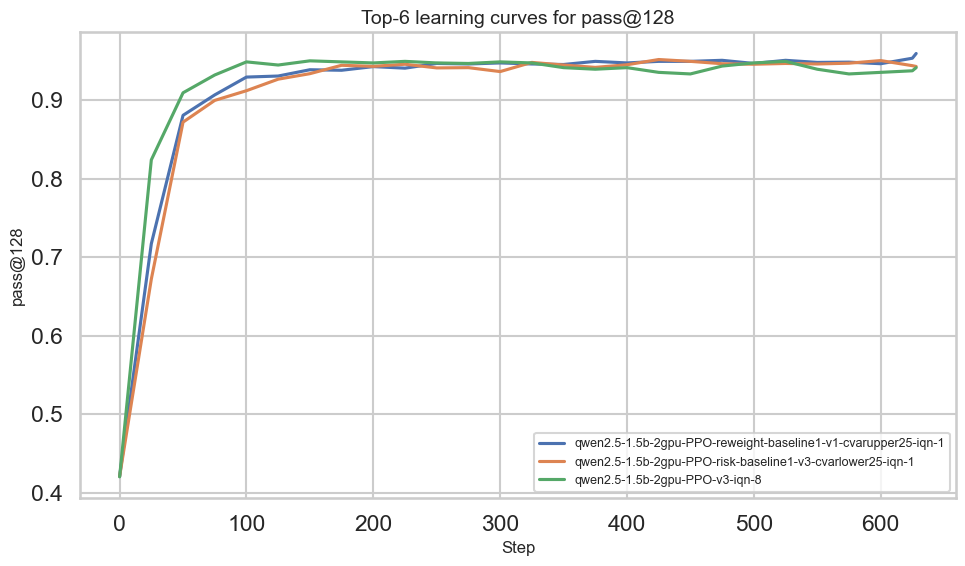

In [8]:
# Plot 1: top-N learning curves per metric
for metric in metric_cols:
    tops = top_algorithms(metric, top_n=6)
    df = agg[agg["algorithm"].isin(tops)]
    new_fig(f"Top-6 learning curves for {metric}")
    sns.lineplot(data=df, x="Step", y=metric, hue="algorithm")
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()


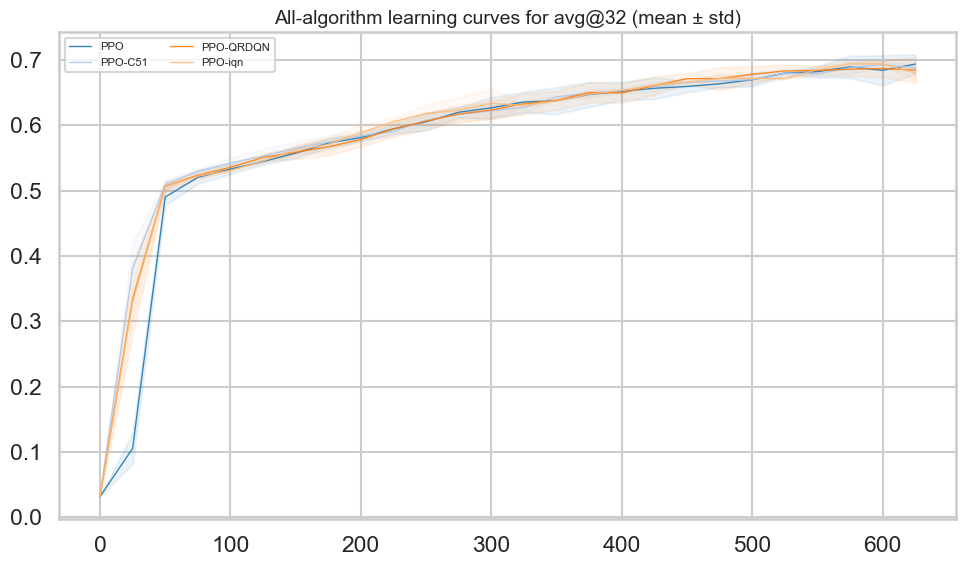

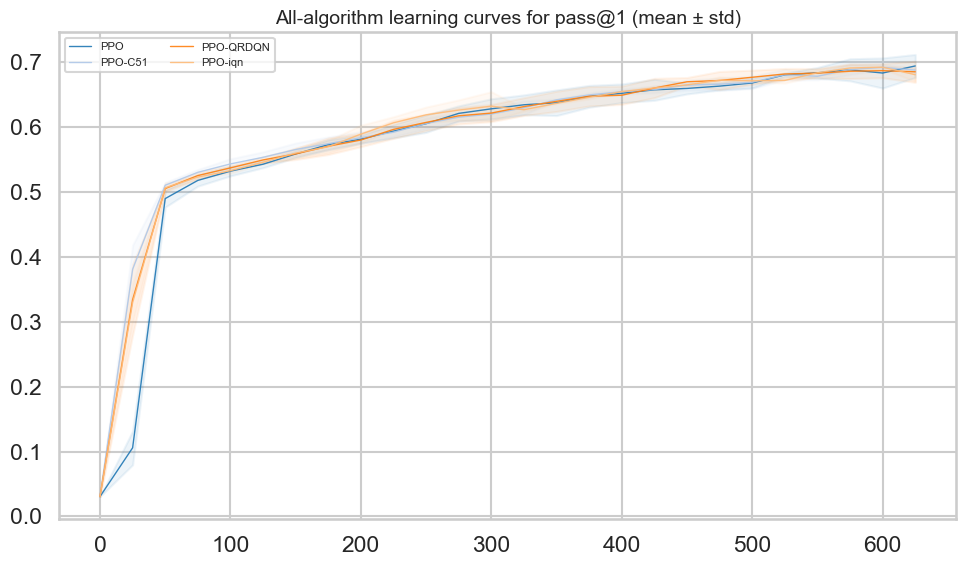

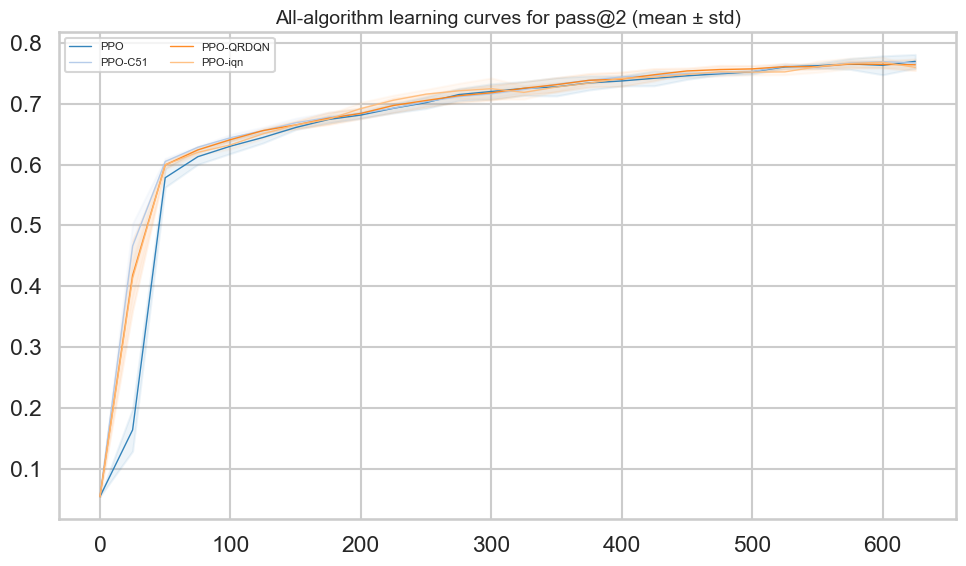

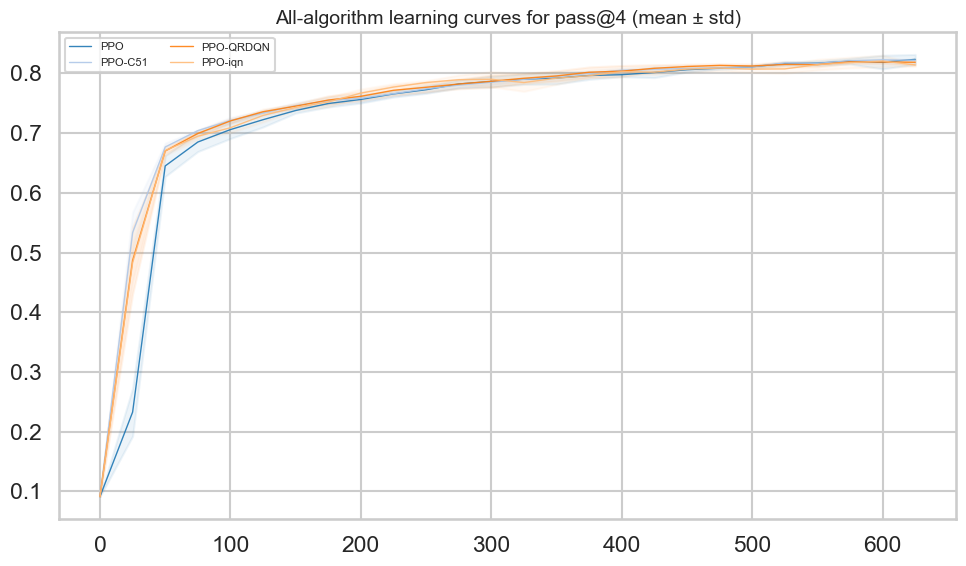

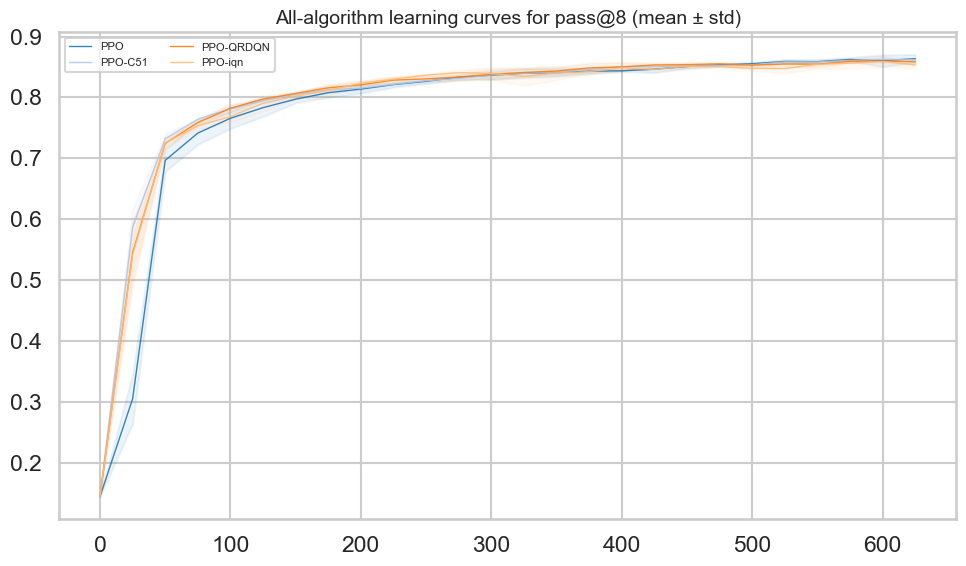

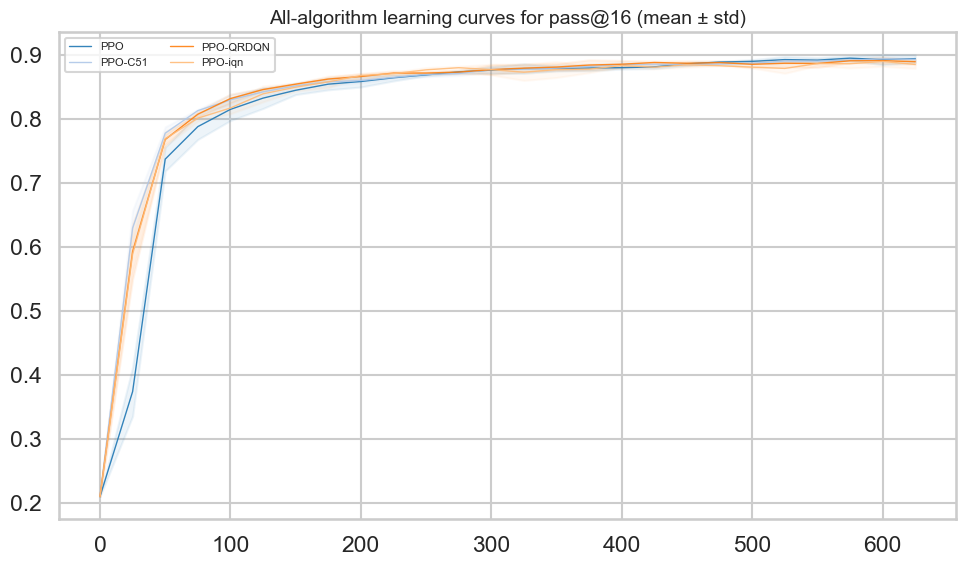

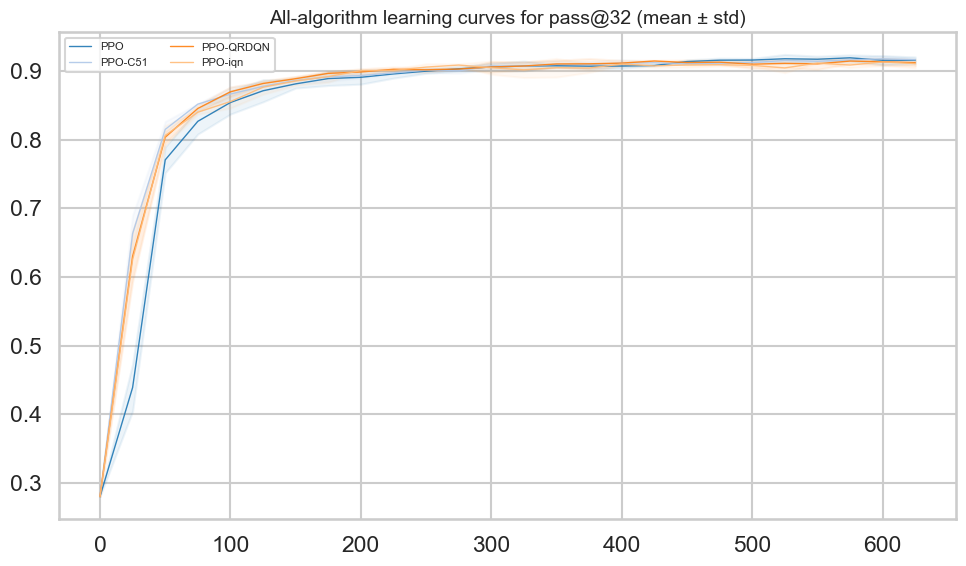

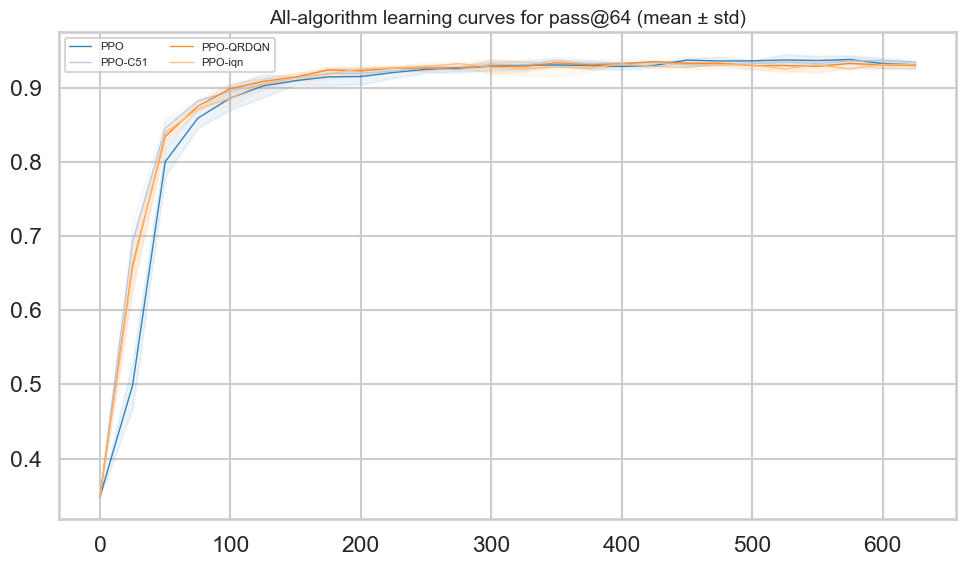

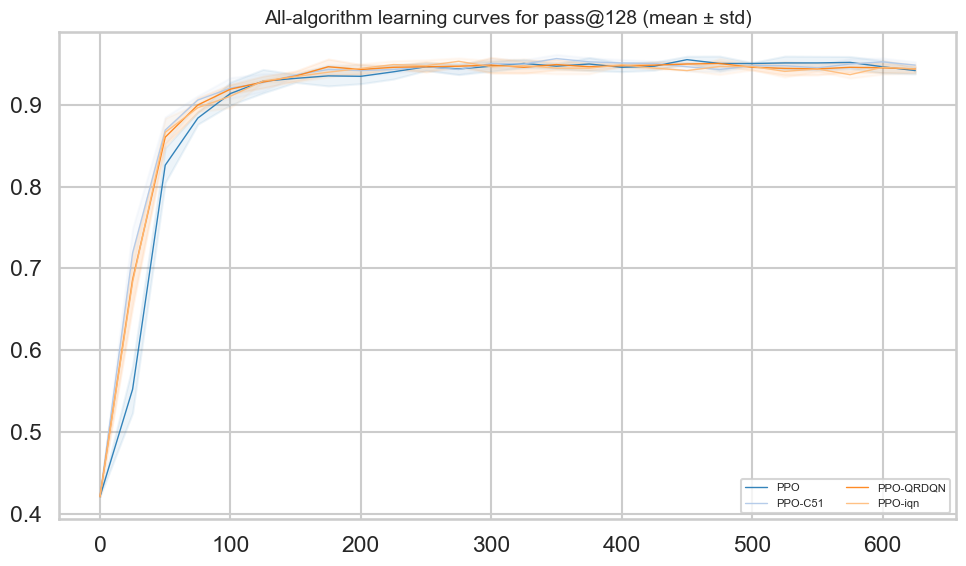

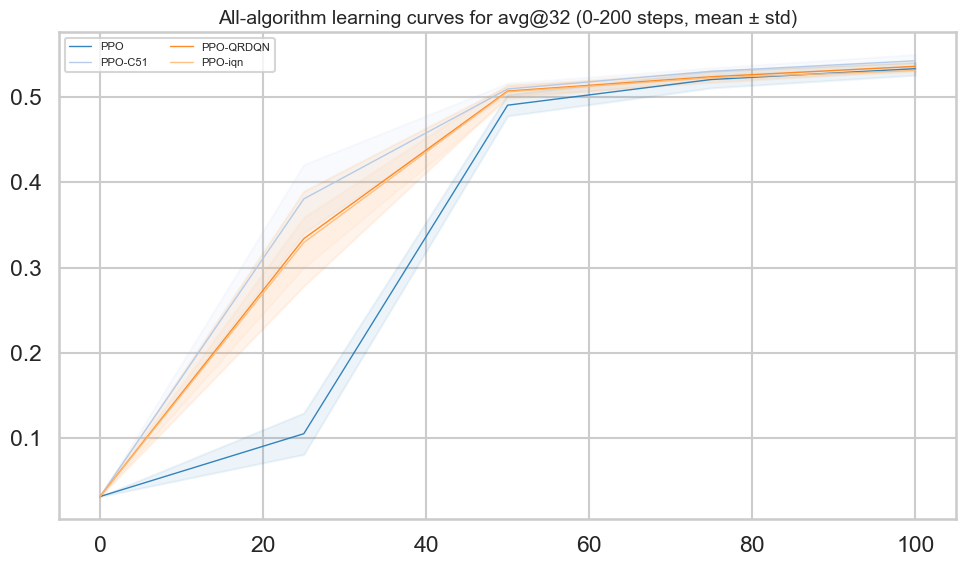

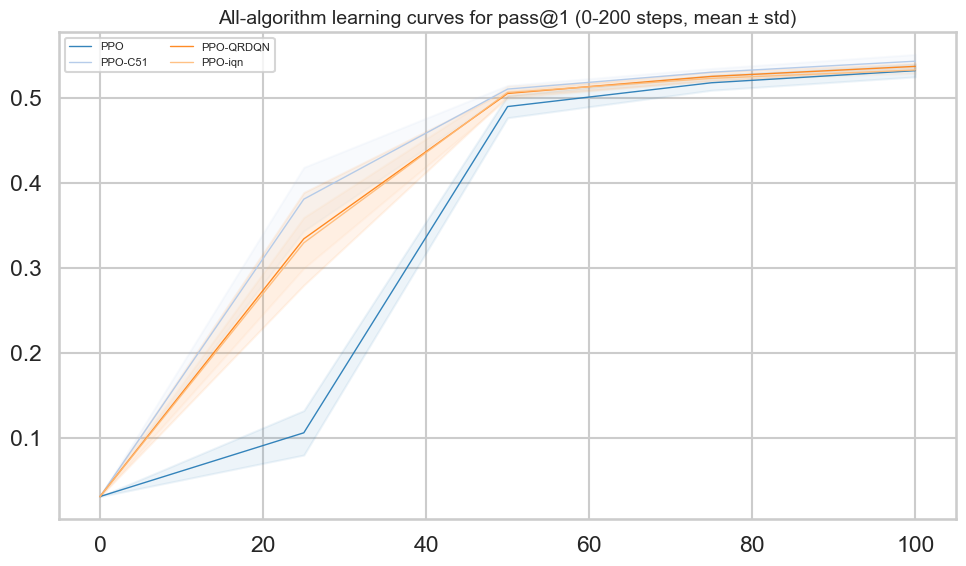

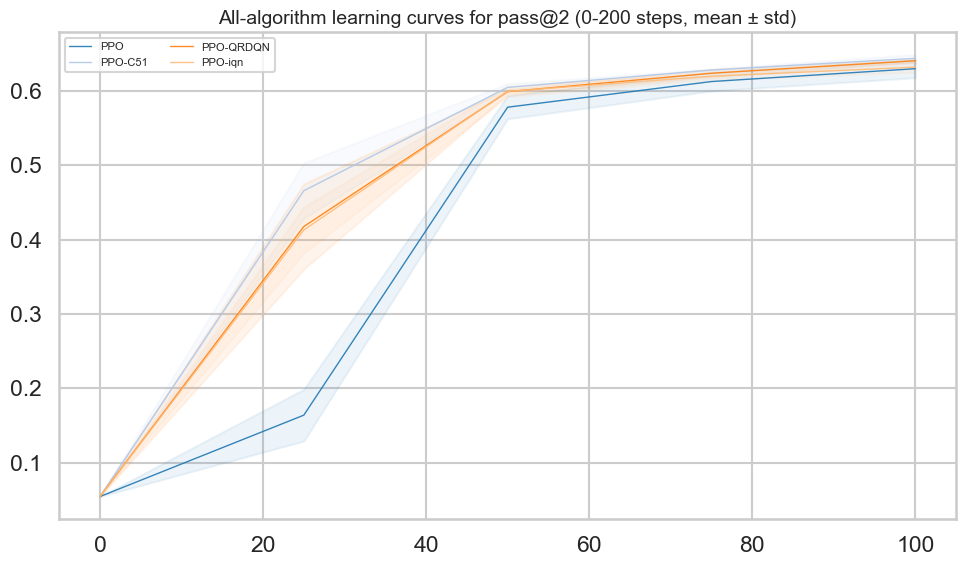

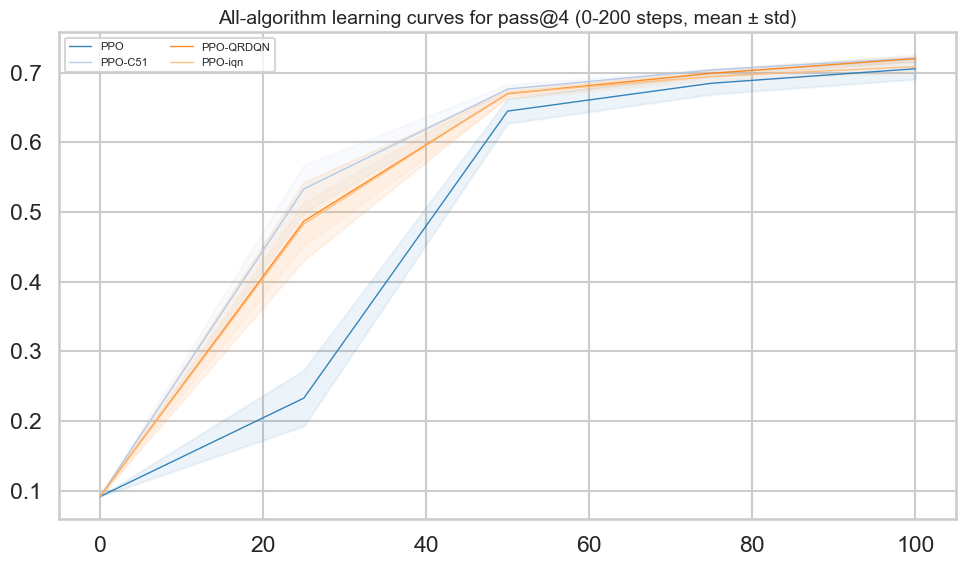

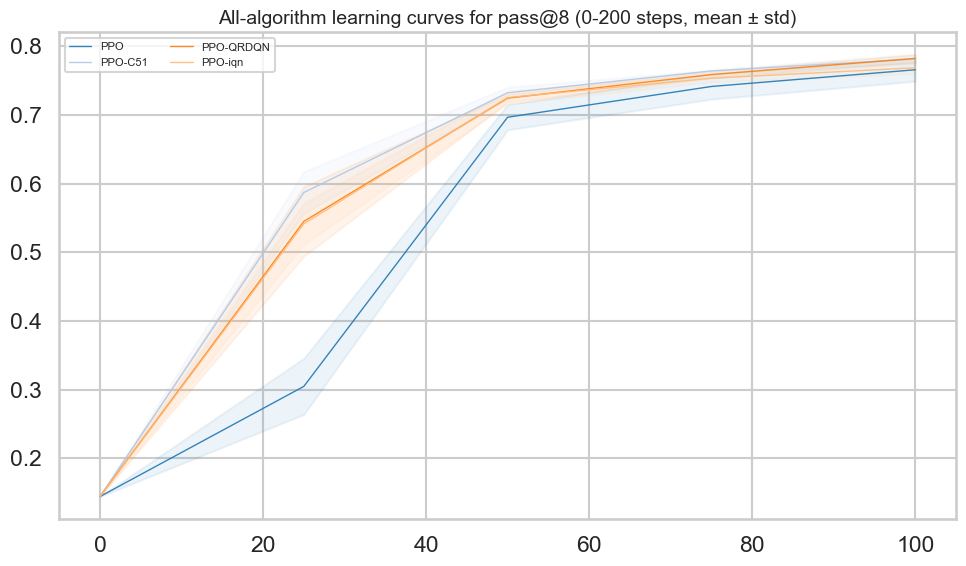

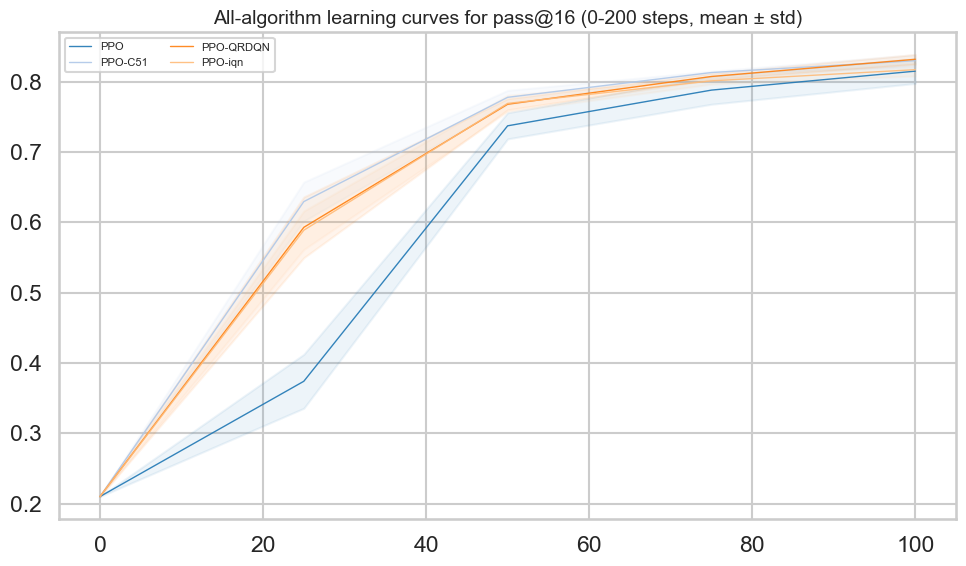

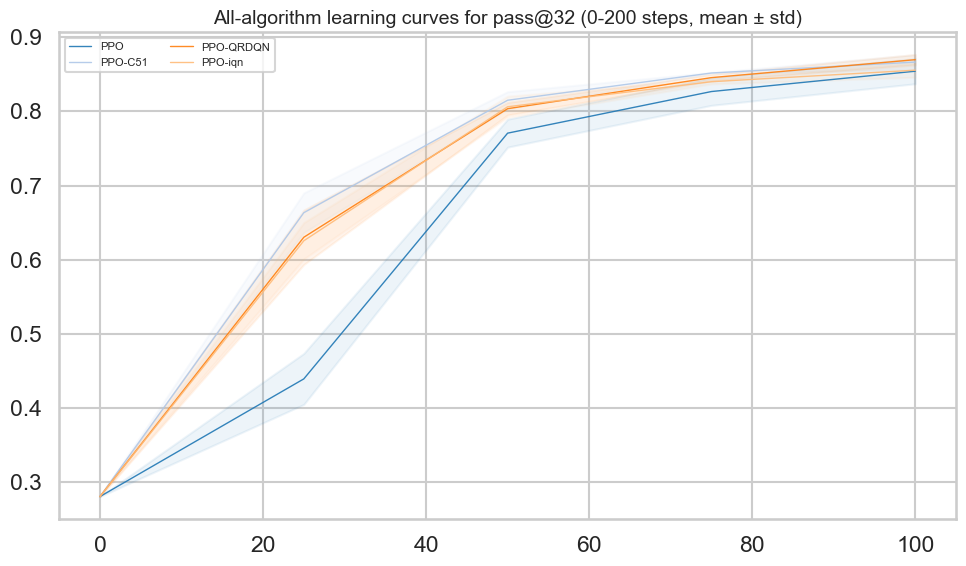

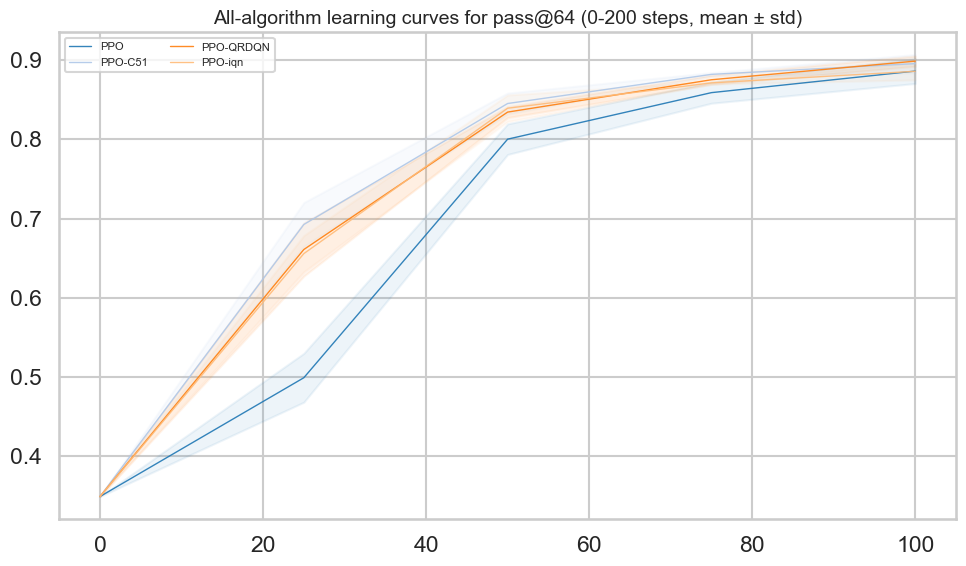

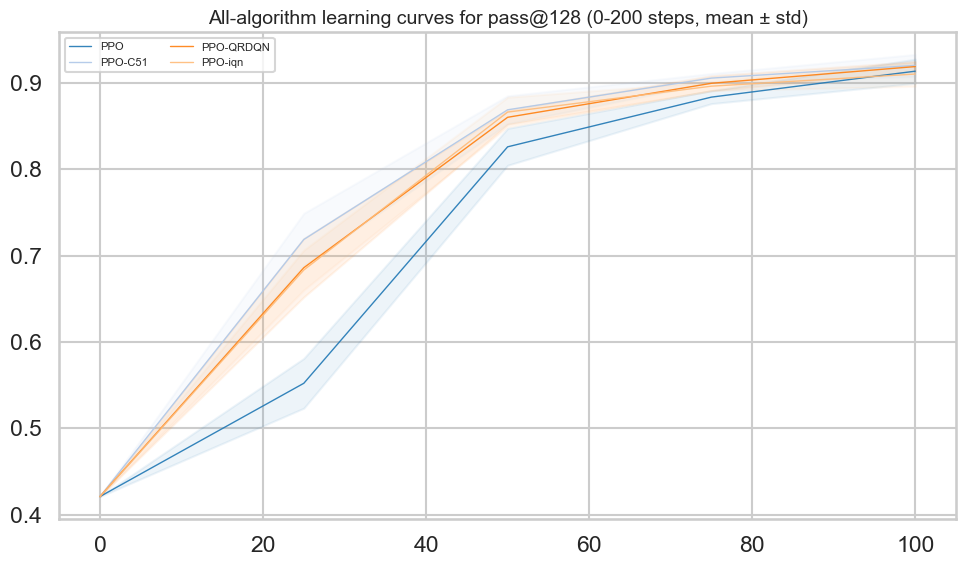

In [13]:
# Plot 2: all algorithms learning curves per metric (mean ± std across seeds)

prefix = "qwen2.5-1.5b-2gpu-"

# List all algorithms (from combined_wide.csv)
all_algorithms = [
    "qwen2.5-1.5b-2gpu-GRPO",
    "qwen2.5-1.5b-2gpu-PPO",
    "qwen2.5-1.5b-2gpu-PPO-2",
    "qwen2.5-1.5b-2gpu-PPO-8",
    "qwen2.5-1.5b-2gpu-PPO-C51",
    "qwen2.5-1.5b-2gpu-PPO-QRDQN",
    "qwen2.5-1.5b-2gpu-PPO-iqn",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v1-cvarupper25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v1-cvarlower25-iqn",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v1-cvarupper25-iqn",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-v2-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8",
]

# Algorithms to plot (exclude ones ending with -1 or -8)
algorithms_to_plot = [
    # "qwen2.5-1.5b-2gpu-GRPO",
    "qwen2.5-1.5b-2gpu-PPO",
    # "qwen2.5-1.5b-2gpu-PPO-2",
    "qwen2.5-1.5b-2gpu-PPO-C51",
    "qwen2.5-1.5b-2gpu-PPO-QRDQN",
    "qwen2.5-1.5b-2gpu-PPO-iqn",
    # "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v1-cvarlower25-iqn",
    # "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v1-cvarupper25-iqn",
]

plot_df = combined[combined["algorithm"].isin(algorithms_to_plot)].copy()
plot_df["algorithm_clean"] = plot_df["algorithm"].str.replace(prefix, "", regex=False)

clean_names = [a.replace(prefix, "") for a in algorithms_to_plot]
palette = sns.color_palette("tab20", n_colors=len(clean_names))
color_map = dict(zip(clean_names, palette))


def plot_mean_std(df, metric, title):
    stats = (
        df.groupby(["Step", "algorithm_clean"], as_index=False)[metric]
        .agg(mean="mean", std="std")
    )
    new_fig(title)
    for name in clean_names:
        sub = stats[stats["algorithm_clean"] == name].sort_values("Step")
        if sub.empty:
            continue
        mean = sub["mean"].to_numpy()
        std = sub["std"].fillna(0).to_numpy()
        step = sub["Step"].to_numpy()
        color = color_map.get(name)
        plt.plot(step, mean, label=name, linewidth=1, color=color, alpha=0.9)
        plt.fill_between(step, mean - std, mean + std, color=color, alpha=0.08)
    plt.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


# Group 1: full steps
for metric in metric_cols:
    plot_mean_std(plot_df, metric, f"All-algorithm learning curves for {metric} (mean ± std)")

# Group 2: steps 0-200
plot_df_0_200 = plot_df[plot_df["Step"].between(0, 101)]
for metric in metric_cols:
    plot_mean_std(plot_df_0_200, metric, f"All-algorithm learning curves for {metric} (0-200 steps, mean ± std)")


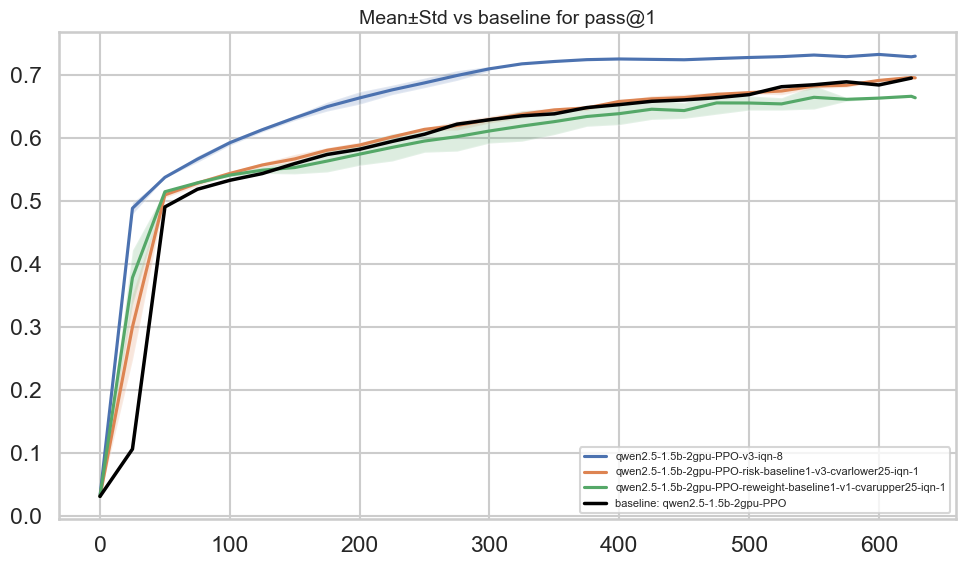

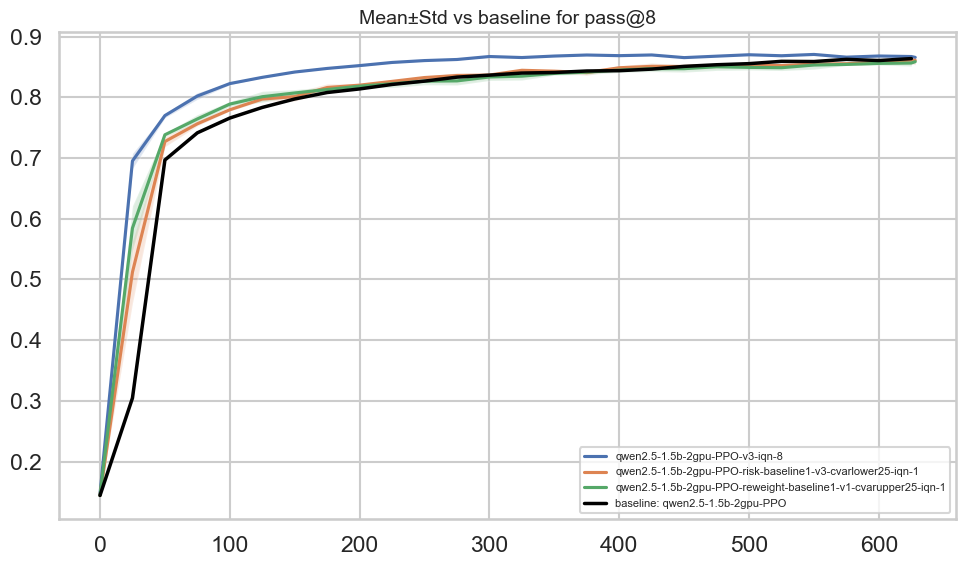

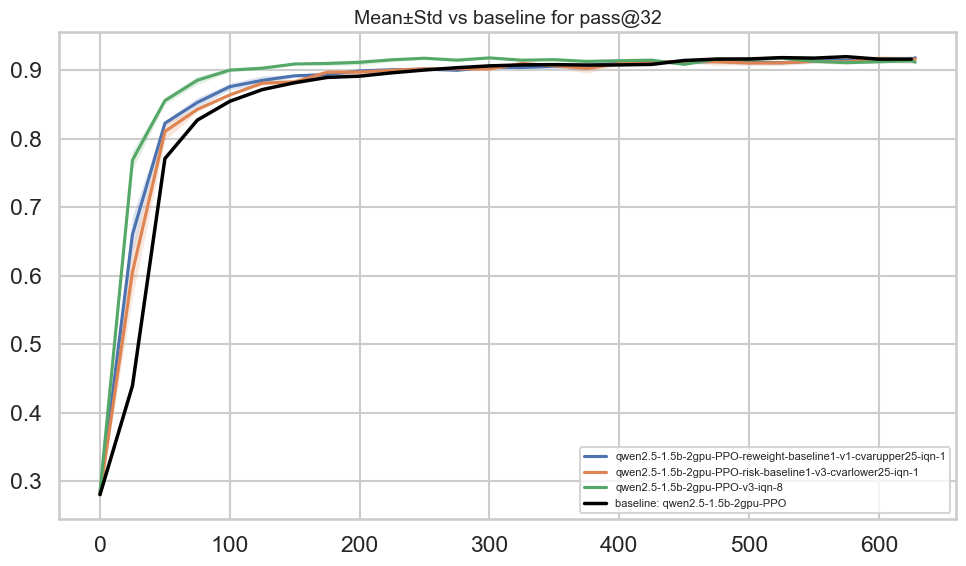

Generated 30 figures


In [10]:
# Plot 3: mean ± std band for key metrics vs a baseline
baseline = "qwen2.5-1.5b-2gpu-PPO"
key_metrics = ["pass@2", "pass@8", "pass@128"]

for metric in key_metrics:
    new_fig(f"Mean±Std vs baseline for {metric}")
    for algo in top_algorithms(metric, top_n=3):
        sub = combined[combined["algorithm"] == algo]
        stats = sub.groupby("Step")[metric].agg(["mean", "std"]).reset_index()
        plt.plot(stats["Step"], stats["mean"], label=algo)
        plt.fill_between(stats["Step"], stats["mean"] - stats["std"], stats["mean"] + stats["std"], alpha=0.2)
    if baseline in combined["algorithm"].unique():
        sub = combined[combined["algorithm"] == baseline]
        stats = sub.groupby("Step")[metric].agg(["mean", "std"]).reset_index()
        plt.plot(stats["Step"], stats["mean"], label=f"baseline: {baseline}", linewidth=2.5, color="black")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

print(f"Generated {PLOT_COUNTER} figures")


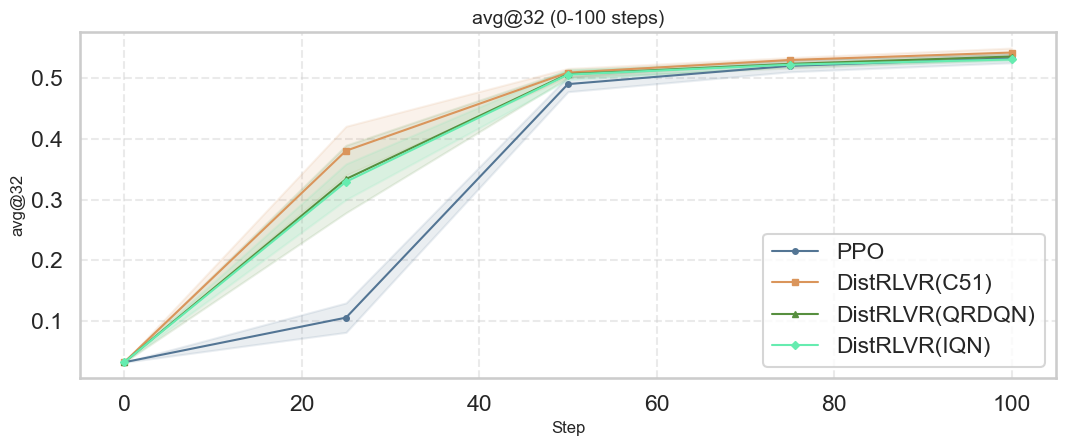

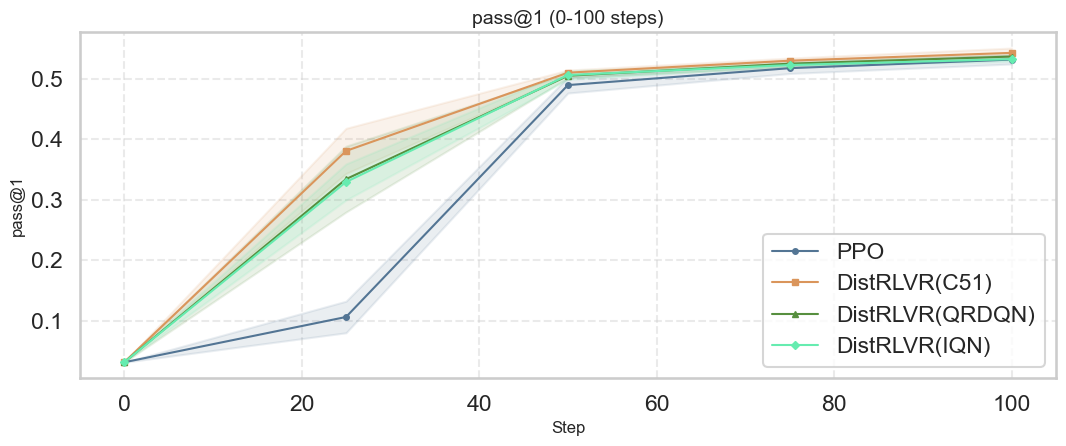

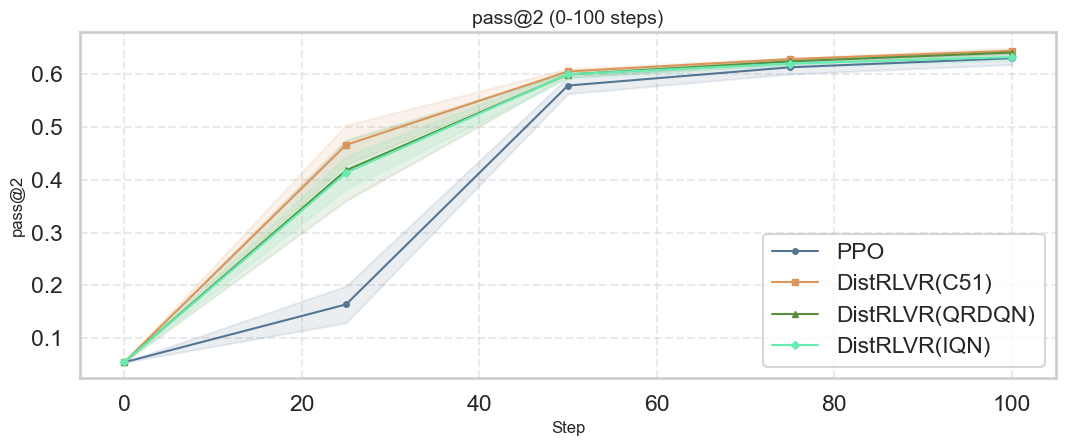

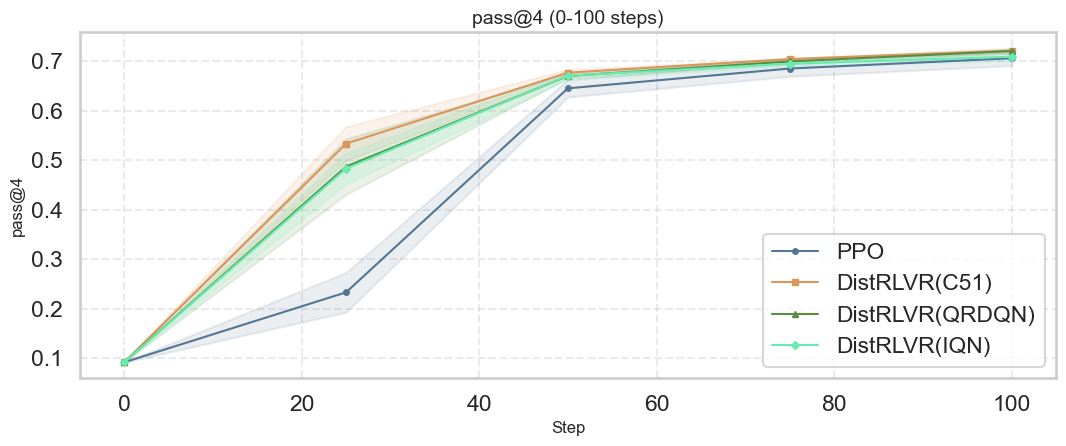

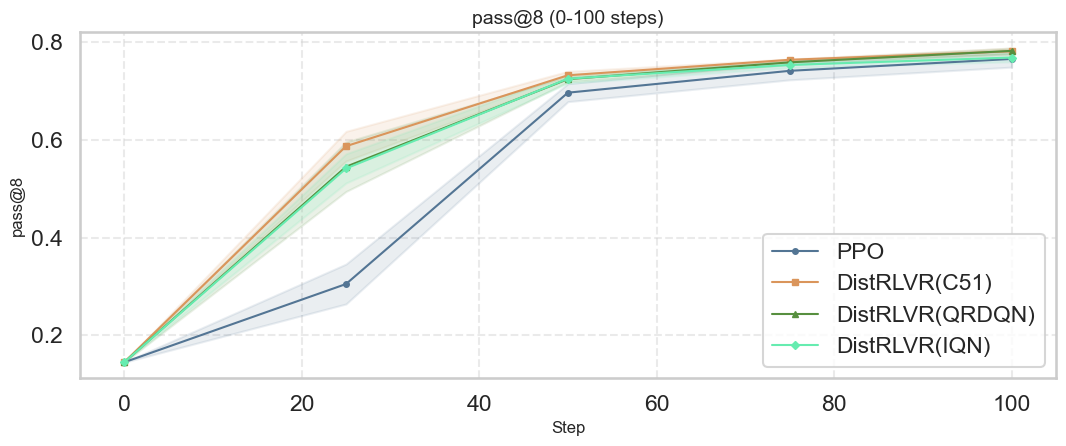

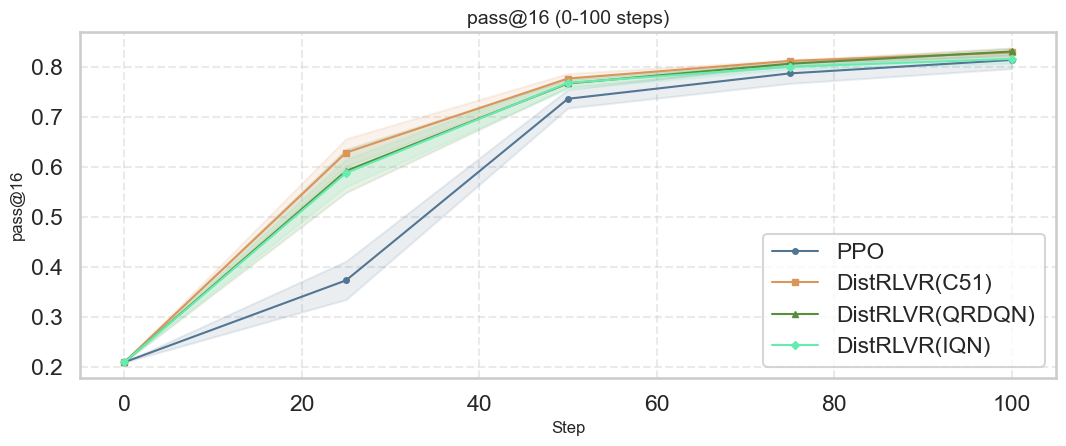

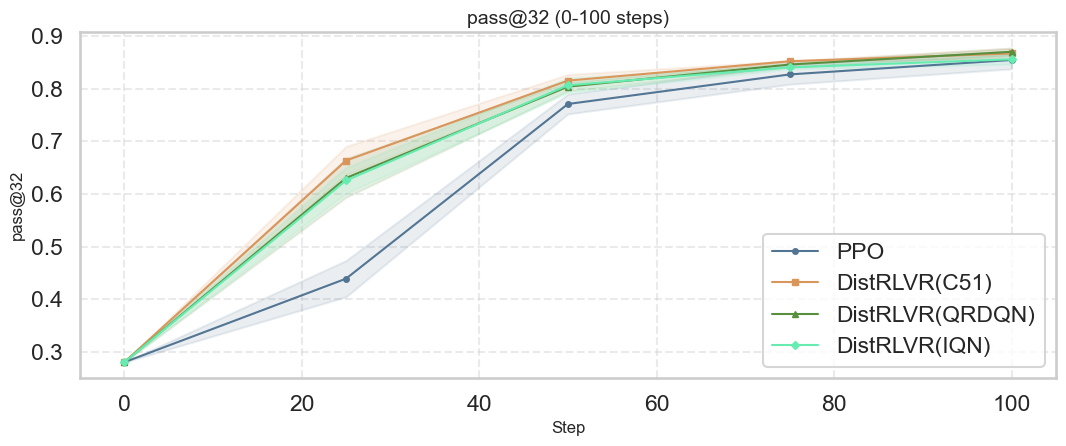

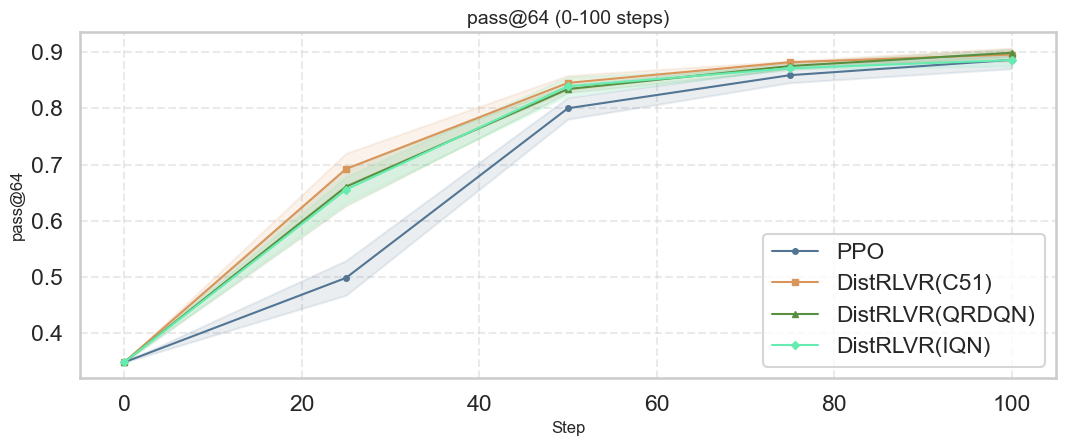

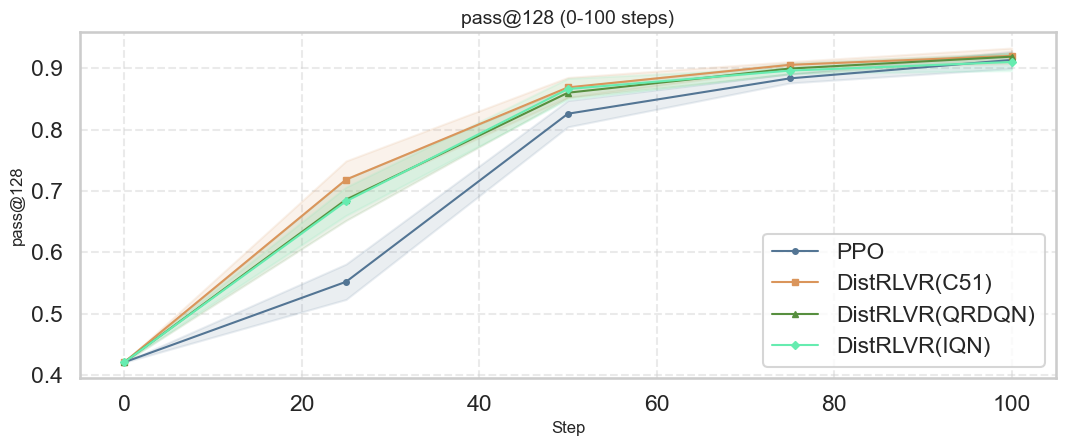

In [19]:
# Plot 3: 0-100 steps, four algorithms (mean ± std across seeds)
prefix = "qwen2.5-1.5b-2gpu-"

label_to_algo = {
    "PPO": "qwen2.5-1.5b-2gpu-PPO",
    "DistRLVR(C51)": "qwen2.5-1.5b-2gpu-PPO-C51",
    "DistRLVR(QRDQN)": "qwen2.5-1.5b-2gpu-PPO-QRDQN",
    "DistRLVR(IQN)": "qwen2.5-1.5b-2gpu-PPO-iqn",
}

focus_labels = list(label_to_algo.keys())
focus_algos = [label_to_algo[k] for k in focus_labels]

focus_df = combined[combined["algorithm"].isin(focus_algos)].copy()
focus_df = focus_df[focus_df["Step"].between(0, 100)]
algo_to_label = {v: k for k, v in label_to_algo.items()}
focus_df["label"] = focus_df["algorithm"].map(algo_to_label)

# Muted, premium-ish palette
colors = ["#537594", "#DA955B", "#578F3F", "#66ECB0"]
markers = ["o", "s", "^", "D"]
color_map = dict(zip(focus_labels, colors))
marker_map = dict(zip(focus_labels, markers))

for metric in metric_cols:
    stats = (
        focus_df.groupby(["Step", "label"], as_index=False)[metric]
        .agg(mean="mean", std="std")
    )

    plt.figure(figsize=(11, 4.8))
    for label in focus_labels:
        sub = stats[stats["label"] == label].sort_values("Step")
        if sub.empty:
            continue
        step = sub["Step"].to_numpy()
        mean = sub["mean"].to_numpy()
        std = sub["std"].fillna(0).to_numpy()
        color = color_map[label]
        marker = marker_map[label]
        plt.plot(
            step,
            mean,
            marker=marker,
            linewidth=1.5,
            markersize=4,
            label=label,
            color=color,
        )
        plt.fill_between(step, mean - std, mean + std, color=color, alpha=0.12)

    plt.title(f"{metric} (0-100 steps)")
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


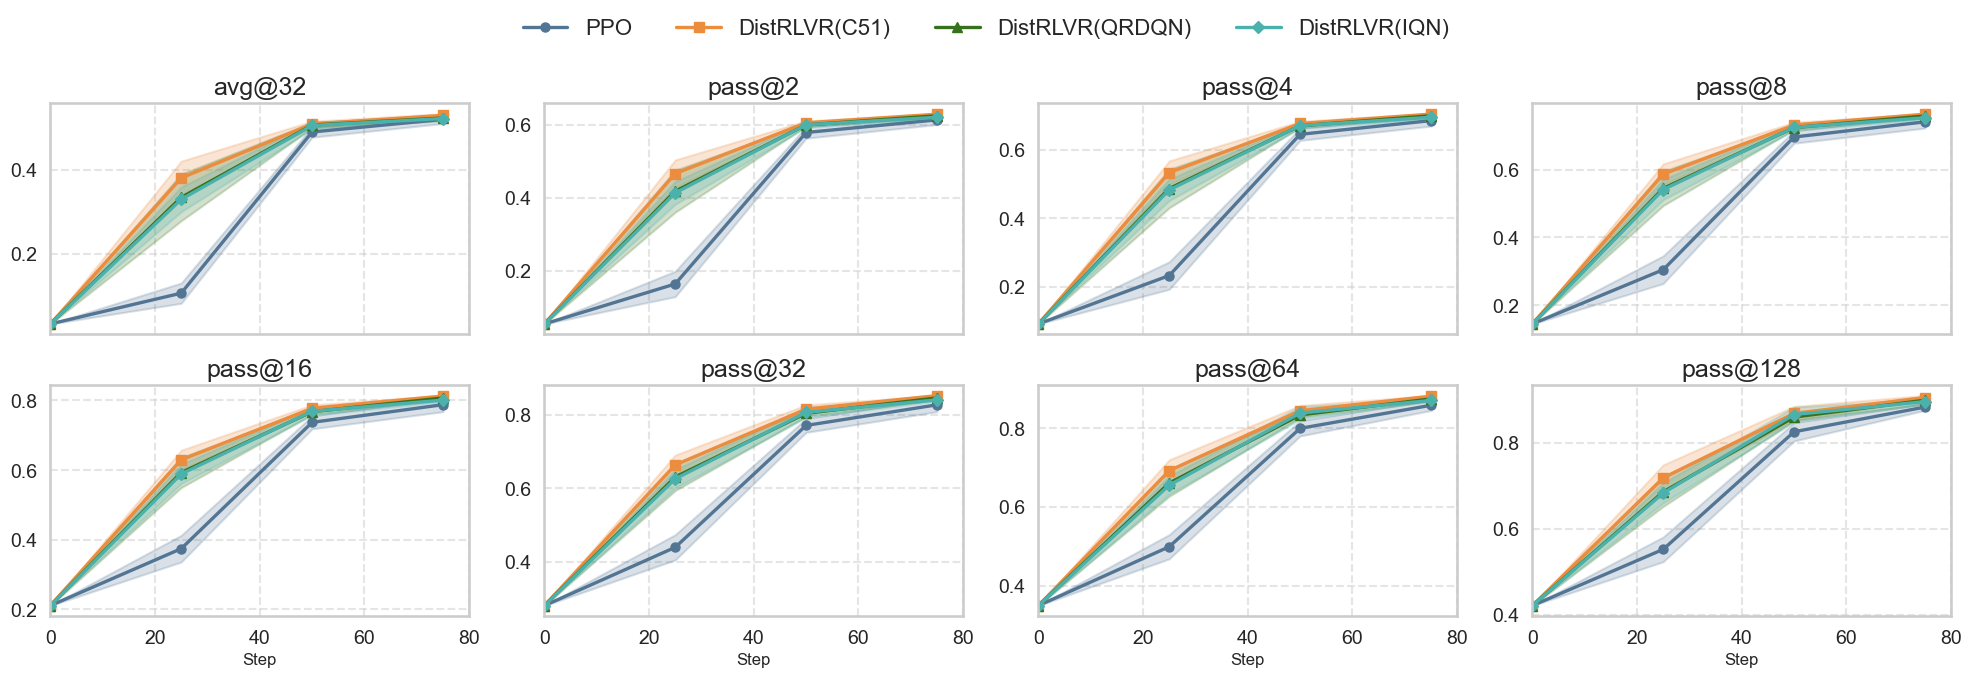

In [35]:
# Plot 4: 0-80 steps, 8 metrics in a 2x4 grid (mean ± std across seeds)
prefix = "qwen2.5-1.5b-2gpu-"

label_to_algo = {
    "PPO": "qwen2.5-1.5b-2gpu-PPO",
    "DistRLVR(C51)": "qwen2.5-1.5b-2gpu-PPO-C51",
    "DistRLVR(QRDQN)": "qwen2.5-1.5b-2gpu-PPO-QRDQN",
    "DistRLVR(IQN)": "qwen2.5-1.5b-2gpu-PPO-iqn",
}

focus_labels = list(label_to_algo.keys())
focus_algos = [label_to_algo[k] for k in focus_labels]

focus_df = combined[combined["algorithm"].isin(focus_algos)].copy()
focus_df = focus_df[focus_df["Step"].between(0, 80)]
algo_to_label = {v: k for k, v in label_to_algo.items()}
focus_df["label"] = focus_df["algorithm"].map(algo_to_label)

# Metrics to plot (no pass@1)
metric_cols = ["avg@32", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]

# Muted, premium-ish palette (tuned 4th color)
colors = ["#537594", "#EB8C3E", "#36721C", "#4AB1AC"]
markers = ["o", "s", "^", "D"]
color_map = dict(zip(focus_labels, colors))
marker_map = dict(zip(focus_labels, markers))

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

fig, axes = plt.subplots(2, 4, figsize=(20, 6.8), sharex=True)
axes = axes.flatten()

legend_handles = None
legend_labels = None

for ax, metric in zip(axes, metric_cols):
    stats = (
        focus_df.groupby(["Step", "label"], as_index=False)[metric]
        .agg(mean="mean", std="std")
    )

    for label in focus_labels:
        sub = stats[stats["label"] == label].sort_values("Step")
        if sub.empty:
            continue
        step = sub["Step"].to_numpy()
        mean = sub["mean"].to_numpy()
        std = sub["std"].fillna(0).to_numpy()
        color = color_map[label]
        marker = marker_map[label]
        line = ax.plot(
            step,
            mean,
            marker=marker,
            linewidth=2.4,
            markersize=6.5,
            label=label,
            color=color,
        )
        ax.fill_between(step, mean - std, mean + std, color=color, alpha=0.22)

    ax.set_title(f"{metric}")
    ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlim(0, 80)
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

# Only bottom row gets x-axis labels
for ax in axes[:4]:
    ax.tick_params(labelbottom=False, width=1.4, length=6)
    ax.set_xlabel("")
for ax in axes[4:]:
    ax.set_xlabel("Step")
    ax.tick_params(width=1.4, length=6)

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("final_results/figs/overview_learning_curves_0_80.pdf", bbox_inches="tight")
plt.show()
